In [1]:
import pandas as pd
import numpy as np
import glob
import seaborn as sns

In [11]:
df = pd.DataFrame()
for i in glob.glob("data/*/*nodes*"):
    tmp = pd.read_csv(i)
    df = pd.concat([df, tmp])
    print(tmp.columns)
    break

Index(['ID_chainID', 'ID_resSeq', 'ID_iCode', 'ID_serial', 'ID_altLoc',
       'ID_resName', 'ID_name', 'atom_index', 'residue_index', 'atom_type',
       'residue_type', 'center_x', 'center_y', 'center_z', 'radius',
       'sas_area', 'solvdir_x', 'solvdir_y', 'solvdir_z', 'voromqa_sas_energy',
       'voromqa_depth', 'voromqa_score_a', 'voromqa_score_r', 'volume',
       'volume_vdw', 'ev14', 'ev28', 'ev56', 'ufsr_a1', 'ufsr_a2', 'ufsr_a3',
       'ufsr_b1', 'ufsr_b2', 'ufsr_b3', 'ufsr_c1', 'ufsr_c2', 'ufsr_c3',
       'buriedness', 'pocketness'],
      dtype='object')


In [12]:
df = pd.DataFrame()
count=0
for i in glob.glob("data/*/*nodes*"):
    tmp = pd.read_csv(i)
    df = pd.concat([df, tmp], ignore_index=True)



In [13]:
dictms = {}
df2 = df.copy()
cols = ['radius',
       'sas_area', 'solvdir_x', 'solvdir_y', 'solvdir_z', 'voromqa_sas_energy',
         'voromqa_score_a', 'voromqa_score_r', 'volume',
       'volume_vdw', 'ev14', 'ev28', 'ev56', 'ufsr_a1', 'ufsr_a2', 'ufsr_a3',
       'ufsr_b1', 'ufsr_b2', 'ufsr_b3', 'ufsr_c1', 'ufsr_c2', 'ufsr_c3']
for col in df.columns:
    if col in cols:
        std = df[col].std()
        mean = df[col].mean()
        dictms[col] = {'mean' : mean, 'std' : std}
        df2[col] = (df[col] - mean)/std
print(pd.DataFrame(dictms).T)

                           mean           std
radius                 1.762311      0.157376
sas_area               6.899288     11.609913
solvdir_x             -0.001289      0.458154
solvdir_y             -0.000978      0.460241
solvdir_z              0.000071      0.459963
voromqa_sas_energy    -0.061555      7.666827
voromqa_score_a        0.456462      0.280125
voromqa_score_r        0.456462      0.222742
volume                25.335040     14.784058
volume_vdw            12.632313      4.172147
ev14                   1.056997      0.768292
ev28                   1.182543      0.825520
ev56                   1.354755      0.851385
ufsr_a1               26.419246     11.748895
ufsr_a2              151.340956    220.770201
ufsr_a3              521.772336   5108.154455
ufsr_b1               37.297349     19.483919
ufsr_b2              250.190954    327.901614
ufsr_b3            -1783.997175  10570.947221
ufsr_c1               35.790337     17.061887
ufsr_c2              253.913259   

In [ ]:
dictms = {}
df2 = df.copy()
cols = ['radius',
       'sas_area', 'solvdir_x', 'solvdir_y', 'solvdir_z', 'voromqa_sas_energy',
         'voromqa_score_a', 'voromqa_score_r', 'volume',
       'volume_vdw', 'ev14', 'ev28', 'ev56', 'ufsr_a1', 'ufsr_a2', 'ufsr_a3',
       'ufsr_b1', 'ufsr_b2', 'ufsr_b3', 'ufsr_c1', 'ufsr_c2', 'ufsr_c3']
for col in df.columns:
    if col in cols:
        sns.displot(df[col])
        std = df[col].std()
        mean = df[col].mean()
        dictms[col] = {'mean' : mean, 'std' : std}
        df2[col] = (df[col] - mean)/std
        sns.displot(df2[col])
print(pd.DataFrame(dictms).T)

In [ ]:
dictms = {}
df2 = df.copy()
cols = ['radius',
       'sas_area', 'solvdir_x', 'solvdir_y', 'solvdir_z', 'voromqa_sas_energy',
         'voromqa_score_a', 'voromqa_score_r', 'volume',
       'volume_vdw', 'ev14', 'ev28', 'ev56', 'ufsr_a1', 'ufsr_a2', 'ufsr_a3',
       'ufsr_b1', 'ufsr_b2', 'ufsr_b3', 'ufsr_c1', 'ufsr_c2', 'ufsr_c3']
for col in df.columns:
    if col in cols:
        sns.displot(df[col])
        std = df[col].std()
        mean = df[col].mean()
        dictms[col] = {'mean' : mean, 'std' : std}
        df2[col] = (df[col] - mean)/std
        sns.displot(df2[col])
print(pd.DataFrame(dictms).T)

In [16]:
cols = ['radius',
      'sas_area', 'solvdir_x', 'solvdir_y', 'solvdir_z', 'voromqa_sas_energy',
      'voromqa_score_a', 'voromqa_score_r', 'volume',
      'volume_vdw', 'ev14', 'ev28', 'ev56', 'ufsr_a1', 'ufsr_a2', 'ufsr_a3',
      'ufsr_b1', 'ufsr_b2', 'ufsr_b3', 'ufsr_c1', 'ufsr_c2', 'ufsr_c3']

for i in glob.glob("data/*/*node*"):
    df3 = pd.read_csv(i)
    for col in df3.columns:
        if col in cols:
            df3[col] = (df3[col] - dictms[col]['mean'])/dictms[col]['std']
    df3.to_csv("data_norm"+i[4:])

In [22]:
df4 = pd.DataFrame()
for i in glob.glob("data/*/*link*"):
    tmp = pd.read_csv(i)
    df4 = pd.concat([df4, tmp])

                    mean       std
area            3.389099  3.547709
boundary        0.601593  1.301420
distance        3.079466  1.441131
voromqa_energy -0.408437  2.028515


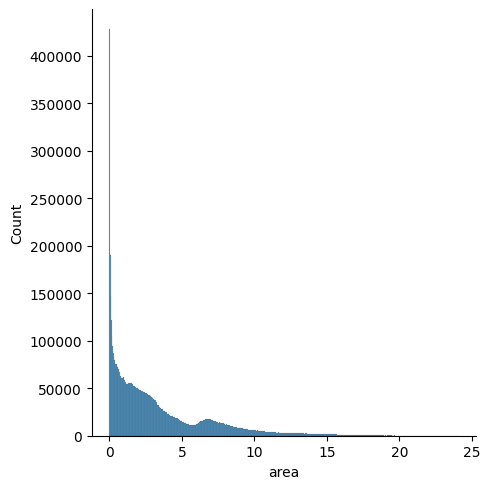

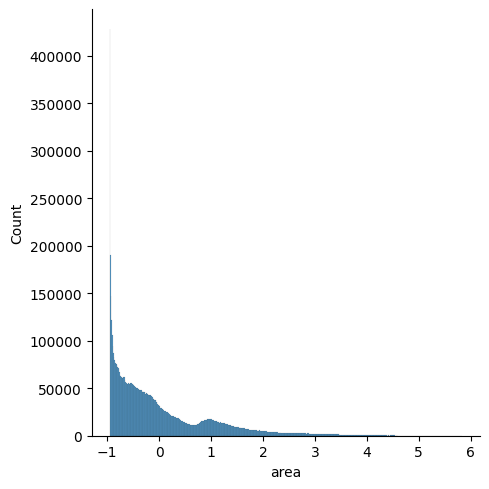

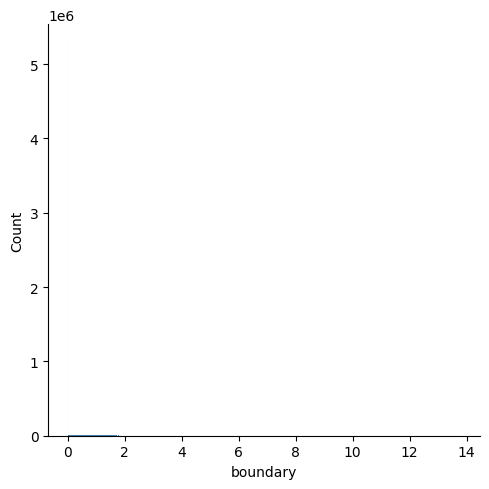

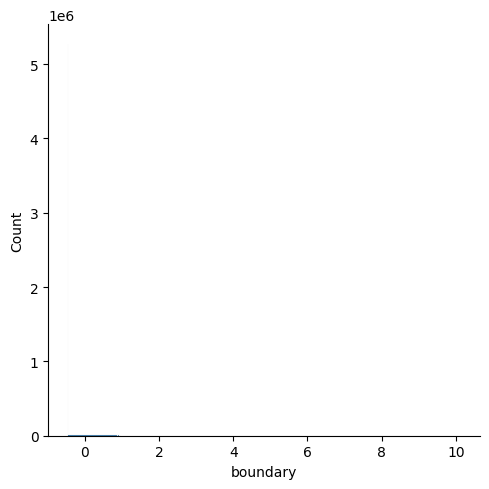

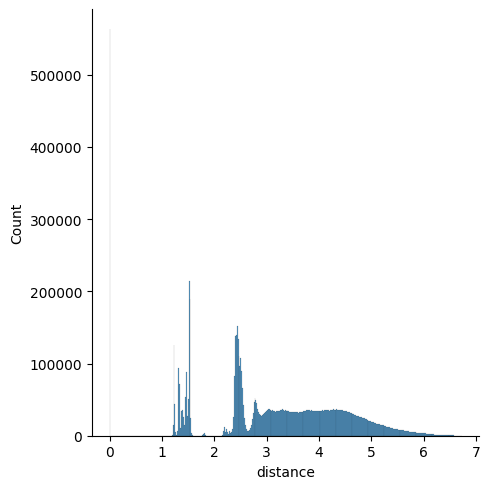

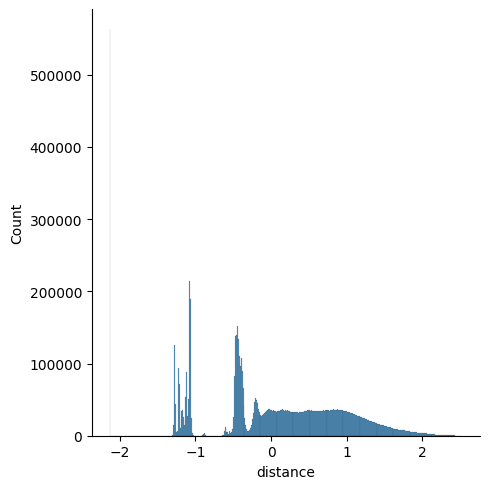

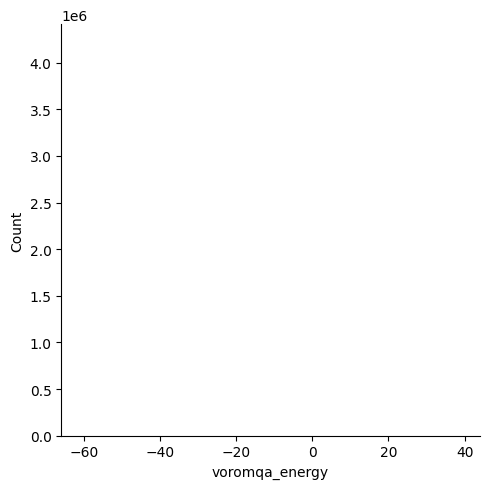

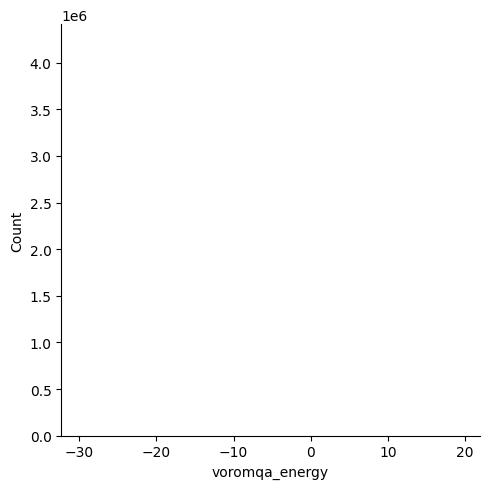

In [23]:
dictms = {}
df5 = df4.copy()
cols = ['area', 'boundary', 'distance',
       'voromqa_energy']
for col in df5.columns:
    if col in cols:
        sns.displot(df5[col])
        std = df5[col].std()
        mean = df5[col].mean()
        dictms[col] = {'mean' : mean, 'std' : std}
        df5[col] = (df5[col] - mean)/std
        sns.displot(df5[col])
print(pd.DataFrame(dictms).T)

In [24]:
for i in glob.glob("data/*/*link*"):
    df6 = pd.read_csv(i)
    for col in df6.columns:
        if col in cols:
            df6[col] = (df6[col] - dictms[col]['mean'])/dictms[col]['std']
    df6.to_csv("data_norm"+i[4:])